In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

def load_and_process_csvs(file1_path, file2_path):
    # Load File 1: simplified format with Mean_red_levels
    df1 = pd.read_csv(file1_path, index_col=0)  # First column is unnamed index (row number)
    
    # Load File 2: contains losses and alphas
    df2 = pd.read_csv(file2_path)

    # Parse alphas from file2
    df2['ALPHAS_LIST'] = df2['alphas'].str.split(',').apply(
        lambda lst: [float(x.strip()) for x in lst]
    )

    return df1, df2

def plot_data(df1, df2, alpha_names):
    n_steps = len(df1)
    if len(df2) != n_steps:
        print(f"Warning: Number of rows differs! File1: {n_steps}, File2: {len(df2)}")
    
    steps = np.arange(n_steps)  # Use row index as step number

    # Determine number of alphas
    n_alphas = len(df2.iloc[0]['ALPHAS_LIST'])
    if len(alpha_names) != n_alphas:
        raise ValueError(f"Number of alpha names ({len(alpha_names)}) must match number of alphas per row ({n_alphas})")

    # Create subplots
    fig, axes = plt.subplots(5, 1, figsize=(10, 15), sharex=True)
    fig.suptitle('Training Metrics Over Steps')

    # 1. Mean Reduction Level
    axes[0].plot(steps, df1['Mean_red_levels'], 'b-', label='Mean Reduction Level')
    axes[0].set_ylabel('Mean Reduction Level')
    axes[0].grid(True)
    axes[0].legend()

    # 2. Alphas over steps
    alphas_array = np.array(df2['ALPHAS_LIST'].tolist())
    for i in range(n_alphas):
        axes[1].plot(steps, alphas_array[:, i], label=alpha_names[i])
    axes[1].set_ylabel('Alphas')
    axes[1].grid(True)
    axes[1].legend()

    # 3. Entropy Loss
    axes[2].plot(steps, df2['entropy_loss'], 'g-', label='Entropy Loss')
    axes[2].set_ylabel('Entropy Loss')
    axes[2].grid(True)
    axes[2].legend()

    # 4. Time Loss
    axes[3].plot(steps, df2['time_loss'], 'r-', label='Time Loss')
    axes[3].set_ylabel('Time Loss')
    axes[3].grid(True)
    axes[3].legend()

    # 5. Lambda Loss
    axes[4].plot(steps, df2['lambdas_loss'], 'm-', label='Lambda Loss')
    axes[4].set_ylabel('Lambda Loss')
    axes[4].set_xlabel('Step (Row Index)')
    axes[4].grid(True)
    axes[4].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# Example usage:
# Example usage:
# df1, df2 = load_and_process_csvs('file1.csv', 'file2.csv')
# plot_data(df1, df2, ['Alpha_0', 'Alpha_1', 'Alpha_2', 'Alpha_3'])

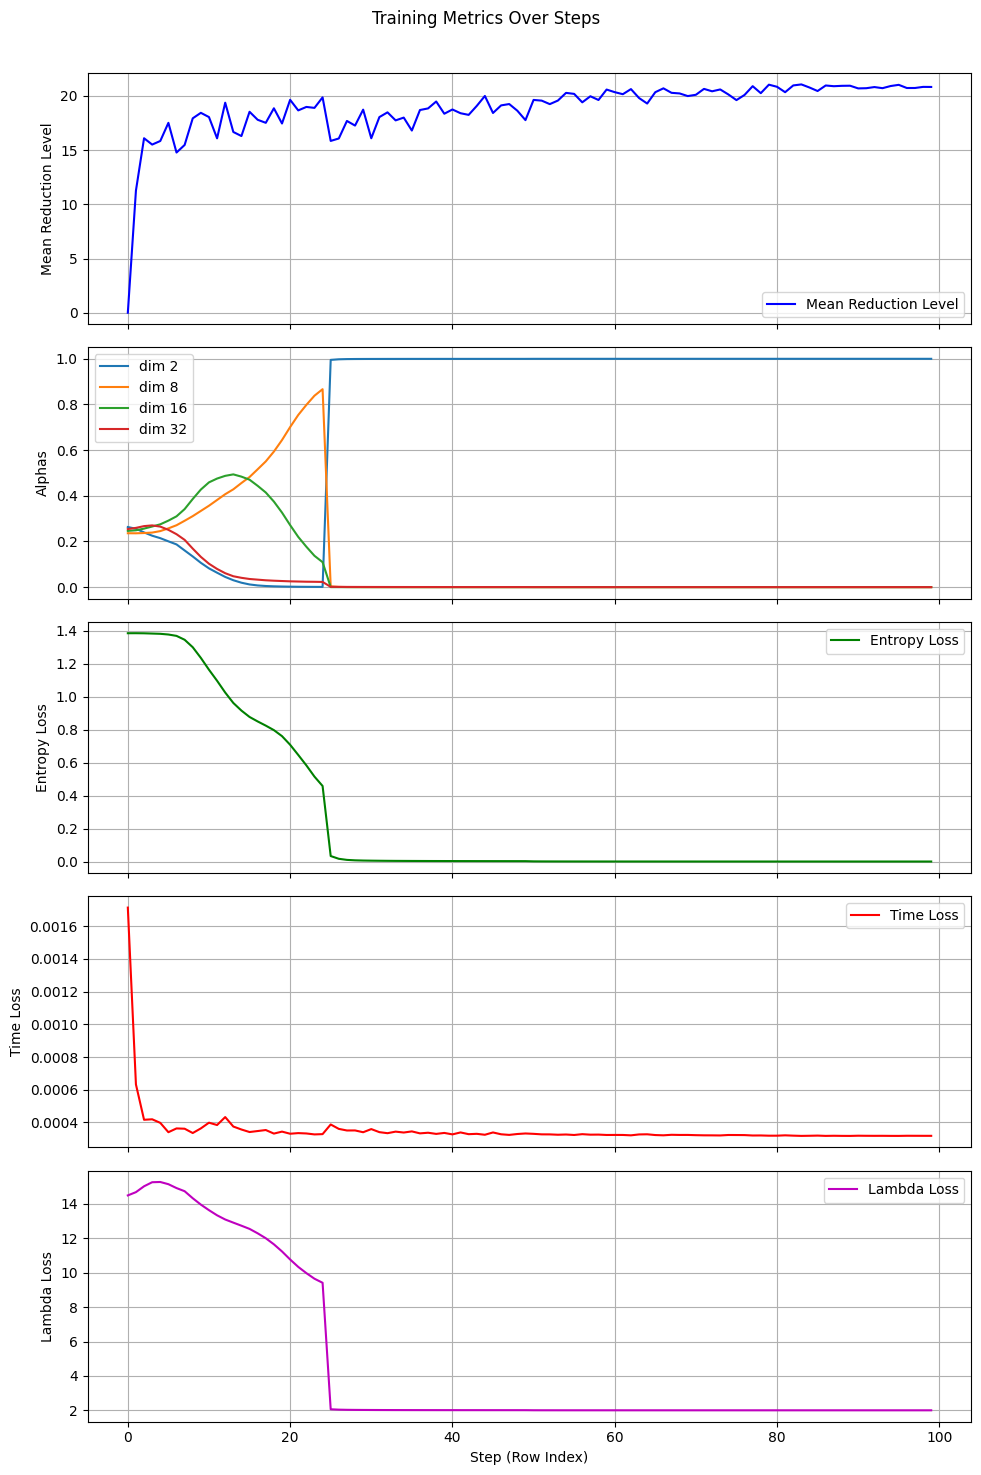

In [15]:
file_one = "/home/dev/work_main/2025/PIMv3/results/mcp_adaptive/data_16TR_2/mcp_real_flat_adaptive/quality_for_iter__seed_0.csv"
file_two = "/home/dev/work_main/2025/PIMv3/results/mcp_adaptive/data_16TR_2/mcp_real_flat_adaptive/best/adaptive_loss_log.csv"
alpha_names = ["dim 2","dim 8","dim 16","dim 32"]

# Load and process data
df1, df2 = load_and_process_csvs(file_one, file_two)

# Define names for alphas (must match the number of alpha values per row in file2)

# Generate the plot
plot_data(df1, df2, alpha_names)
